In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.axes import Axes

In [2]:
df = pd.read_csv(f"../../data_processed/SG_nona.csv")

df

,date,new_confirmed,new_deceased,new_tested,cumulative_confirmed,cumulative_deceased,new_persons_vaccinated,cumulative_persons_vaccinated,new_persons_fully_vaccinated,cumulative_persons_fully_vaccinated,...,search_trends_wheeze,search_trends_xeroderma,search_trends_xerostomia,search_trends_yawn,average_temperature_celsius,minimum_temperature_celsius,maximum_temperature_celsius,rainfall_mm,dew_point,relative_humidity
0,2020-01-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.30,4.45,0.46,0.25,27.816667,25.400000,31.444444,0.406400,23.622222,78.160465
1,2020-01-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.31,4.33,0.44,0.19,27.483333,25.116667,30.522222,1.213556,24.072222,81.775103
2,2020-01-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.28,4.40,0.40,0.21,27.627778,25.266667,31.172222,0.793750,24.255556,82.004853
3,2020-01-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.29,4.78,0.42,0.21,27.200000,24.700000,30.883333,1.682750,23.800000,81.865993
4,2020-01-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.28,4.44,0.41,0.24,27.744444,24.811111,31.872222,0.431800,23.477778,77.721261
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
986,2022-09-13,2426.0,2.0,24000.0,1867168.0,1604.0,60.0,5024384.0,195.0,5004693.0,...,0.39,4.03,0.41,0.22,26.888889,24.544444,30.833333,6.508750,23.700000,82.993906
987,2022-09-14,2426.0,2.0,24000.0,1867168.0,1604.0,60.0,5024384.0,195.0,5004693.0,...,0.39,4.03,0.41,0.22,26.888889,24.544444,30.833333,6.508750,23.700000,82.993906
988,2022-09-15,2426.0,2.0,24000.0,1867168.0,1604.0,60.0,5024384.0,195.0,5004693.0,...,0.39,4.03,0.41,0.22,26.888889,24.544444,30.833333,6.508750,23.700000,82.993906
989,2022-09-16,2426.0,2.0,24000.0,1867168.0,1604.0,60.0,5024384.0,195.0,5004693.0,...,0.39,4.03,0.41,0.22,26.888889,24.544444,30.833333,6.508750,23.700000,82.993906


In [3]:
dates_idx: list[int] = []

for i, date in enumerate(df.date):
    if date[5:7] in {'01', '04', '07', '10'} and date[8:] == '01':
        dates_idx.append(i)

In [4]:
for col in df.columns:
    print(col) if "search" not in col else None

date
new_confirmed
new_deceased
new_tested
cumulative_confirmed
cumulative_deceased
new_persons_vaccinated
cumulative_persons_vaccinated
new_persons_fully_vaccinated
cumulative_persons_fully_vaccinated
new_vaccine_doses_administered
cumulative_vaccine_doses_administered
population
population_male
population_female
population_rural
population_urban
population_largest_city
population_clustered
population_density
human_development_index
population_age_00_09
population_age_10_19
population_age_20_29
population_age_30_39
population_age_40_49
population_age_50_59
population_age_60_69
population_age_70_79
population_age_80_and_older
gdp_usd
gdp_per_capita_usd
human_capital_index
area_sq_km
area_rural_sq_km
area_urban_sq_km
life_expectancy
smoking_prevalence
diabetes_prevalence
infant_mortality_rate
adult_male_mortality_rate
adult_female_mortality_rate
pollution_mortality_rate
comorbidity_mortality_rate
hospital_beds_per_1000
nurses_per_1000
physicians_per_1000
health_expenditure_usd
out_of_po

In [5]:
for col in df.columns:
    print(col) if "search" in col else None

search_trends_abdominal_obesity
search_trends_abdominal_pain
search_trends_acne
search_trends_actinic_keratosis
search_trends_acute_bronchitis
search_trends_adrenal_crisis
search_trends_ageusia
search_trends_alcoholism
search_trends_allergic_conjunctivitis
search_trends_allergy
search_trends_amblyopia
search_trends_amenorrhea
search_trends_amnesia
search_trends_anal_fissure
search_trends_anaphylaxis
search_trends_anemia
search_trends_angina_pectoris
search_trends_angioedema
search_trends_angular_cheilitis
search_trends_anosmia
search_trends_anxiety
search_trends_aphasia
search_trends_aphonia
search_trends_apnea
search_trends_arthralgia
search_trends_arthritis
search_trends_ascites
search_trends_asperger_syndrome
search_trends_asphyxia
search_trends_asthma
search_trends_astigmatism
search_trends_ataxia
search_trends_atheroma
search_trends_attention_deficit_hyperactivity_disorder
search_trends_auditory_hallucination
search_trends_autoimmune_disease
search_trends_avoidant_personality_diso

In [6]:
df["search_trends_abdominal_obesity"]

0      3.86
1      3.64
2      3.55
3      3.92
4      3.79
       ... 
986    2.90
987    2.90
988    2.90
989    2.90
990    2.90
Name: search_trends_abdominal_obesity, Length: 991, dtype: float64

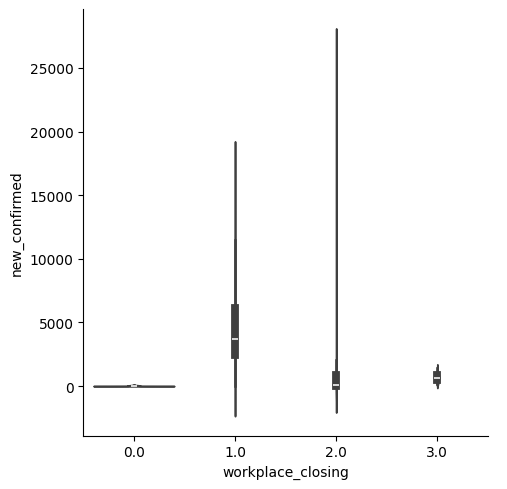

In [7]:
sns.catplot(
    df, 
    x = "workplace_closing",
    y = "new_confirmed",
    kind = "violin",
)

In [10]:
def plot_scatter_on_ax(ax: Axes, df: pd.DataFrame) -> None:
    ax.scatter(df["date"], df[name_column], label = name_column, marker = ".", s = 1)

def configure_axis(ax: Axes, ) -> None:
    ax.set_xticks([df.date[i] for i in dates_idx])

    ax.axhline(0, color = "black", ls = "-", lw = 0.5)
    ax.axvline(df.date[0], color = "black", ls = "-", lw = 0.5)


    ax.tick_params(axis='x', labelrotation=45, labelsize = 7)
    ax.tick_params(axis='x', labelrotation=45, labelsize = 7)

    ax.legend()
    ax.grid(True)

NameError: name 'columns_to_plot' is not defined

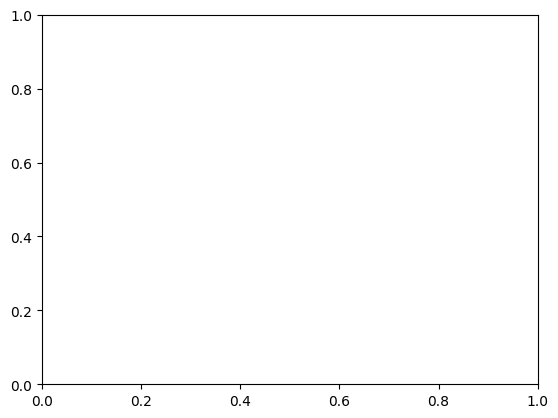

In [ ]:
fig, ax = plt.subplots()

axs = [ax]



for ax, col_name in zip(axs, ):
    plot_scatter_on_ax(ax, df)

for ax in axs:
    configure_axis(ax=ax)